In [8]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(str(Path().resolve().parents[0]))

from scripts.data.modeling import entrenar_modelo
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    ConfusionMatrixDisplay
)


In [9]:
ruta_proyecto = Path().resolve().parents[0]

sys.path.append(str(ruta_proyecto))

ruta_csv = ruta_proyecto / "data" / "processed"

X_modelado = pd.read_csv(ruta_csv / "X_modelado.csv")

y_modelado = pd.read_csv(ruta_csv / "y_modelado.csv")

In [10]:
model, X_test, y_test = entrenar_modelo(
    X_modelado,
    y_modelado
)

C:\Users\ERIKA PINCHAO\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [11]:
# Predicción final de clases
y_pred = model.predict(X_test)

# Probabilidades de supervivencia
y_prob = model.predict_proba(X_test)[:, 1]

In [12]:
print("F1 Score:")
print( f1_score(y_test, y_pred))

F1 Score:
0.7755102040816327


In [13]:
print("AUC Score:")
print( roc_auc_score(y_test, y_prob))

AUC Score:
0.8881595881595881


In [14]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.85      0.84       105
           1       0.78      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [15]:
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

[[89 16]
 [17 57]]


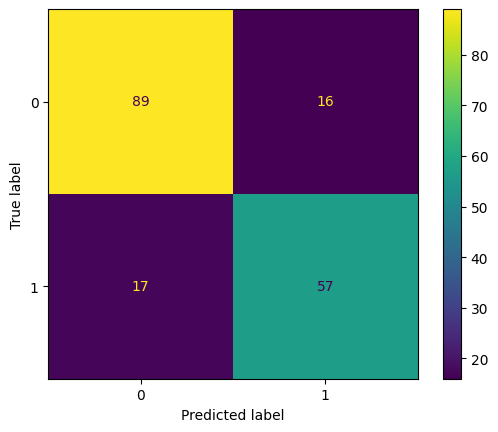

In [16]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

In [17]:
coeficientes = pd.DataFrame({

    "feature": X_modelado.columns,

    "coeficiente": model.coef_[0]
})

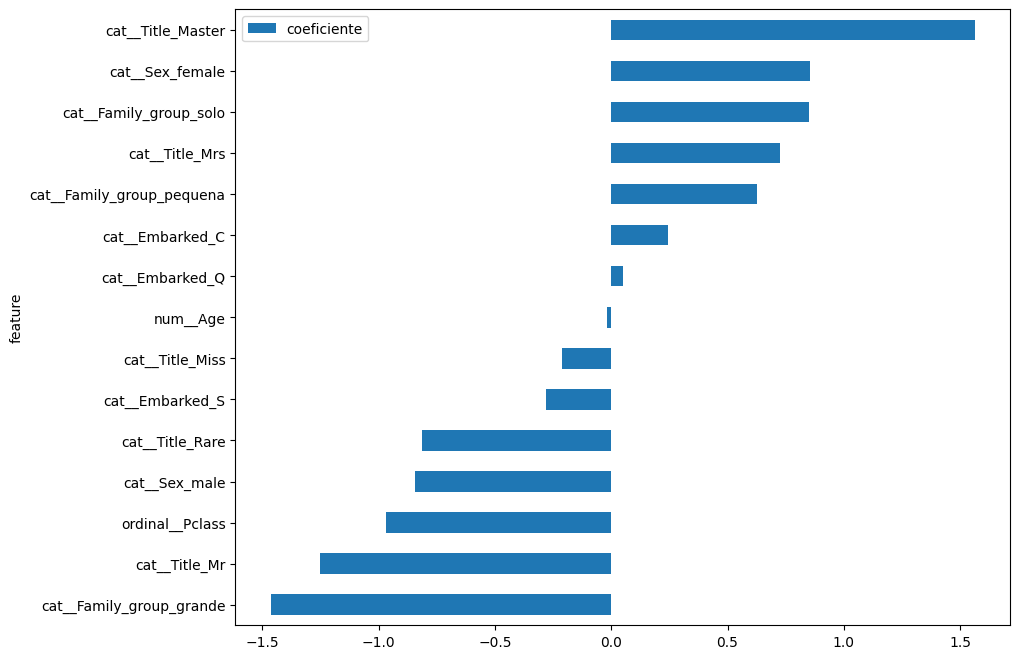

In [18]:
coeficientes_ordenados = coeficientes.sort_values(
    by="coeficiente"
)

coeficientes_ordenados.plot.barh(

    x="feature",

    y="coeficiente",

    figsize=(10,8)
)

plt.show()